# Stage 2 — Dataset Acquisition & Preparation
## Project: Optimizing Indonesian Sentence Embeddings for STS

---
**Pipeline Stage:** 2 of 12  
**Notebook:** `02_dataset_setup.ipynb`

### Cell Structure
```
2.0   Bootstrap: Mount Drive + Import project_config
2.0b  Install libraries + imports
2.1   Load datasets dari HuggingFace
2.1b  Inspect raw schema
2.2   Normalisasi schema
2.3   Text cleaning + Quality filter + Dedup
2.4   EDA: statistik
2.4b  EDA: visualisasi (4 plot)
2.5   Build final splits (train/val/test)
2.6   Export CSV ke Drive
2.6b  Build simcse_sentences.txt
2.6c  Build mining_corpus.txt
2.7   Export dataset_stats.json
2.8   Write src/data_loader.py ke Drive
2.9   Sanity check & verifikasi semua file
```

### Output
```
datasets/splits/train_pairs.csv
datasets/splits/val_pairs.csv
datasets/splits/test_pairs.csv
datasets/splits/simcse_sentences.txt
datasets/mining-corpus/mining_corpus.txt
evaluation/dataset_stats.json
evaluation/eda_score_distribution.png
src/__init__.py
src/data_loader.py            <- di-import Stage 3-10
```
---

In [4]:
# ============================================================
# CELL 2.0 - Bootstrap: Mount Drive + Import project_config
# ============================================================
# Prasyarat: Stage 1 sudah dijalankan (project_config.py ada di Drive)

import sys, os

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_ROOT = "/content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings"
sys.path.insert(0, PROJECT_ROOT)

from project_config import PATHS, HF_CACHE_DIR

os.environ["HF_HOME"]                = HF_CACHE_DIR
os.environ["TRANSFORMERS_CACHE"]     = HF_CACHE_DIR
os.environ["HF_DATASETS_CACHE"]      = HF_CACHE_DIR
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("[OK] Drive mounted & project_config loaded.")
print(f"     PROJECT_ROOT : {PROJECT_ROOT}")
print(f"     HF_CACHE_DIR : {HF_CACHE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] Drive mounted & project_config loaded.
     PROJECT_ROOT : /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings
     HF_CACHE_DIR : /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/hf_cache


In [5]:
# ============================================================
# CELL 2.0b - Install libraries + imports
# ============================================================

!pip install -q datasets sentence-transformers transformers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
import random
import unicodedata
from pathlib import Path
from datasets import load_dataset
from sentence_transformers import InputExample

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style("whitegrid")
random.seed(42)
np.random.seed(42)

print("[OK] Semua imports berhasil.")

[OK] Semua imports berhasil.


In [6]:
# ============================================================
# CELL 2.0c — Setup HF Token dari Colab Secrets
# ============================================================

from google.colab import userdata
import os

try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    os.environ['HF_TOKEN'] = HF_TOKEN

    # Login ke HuggingFace Hub
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("[OK] HuggingFace login berhasil.")
except Exception as e:
    print(f"[WARN] HF Token tidak ditemukan: {e}")
    print("       Beberapa dataset mungkin tidak bisa diakses.")
    print("       Tambahkan HF_TOKEN di Colab Secrets (icon kunci di sidebar).")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


[OK] HuggingFace login berhasil.


In [7]:
# ============================================================
# CELL 2.1 - Load & Translate English STSB -> Indonesian
# ============================================================
# Fix dari run sebelumnya:
#   - split name: 'dev' bukan 'validation'
#   - greedy decoding (num_beams=1) untuk semua split -> cepat
#   - batch_size=128 untuk CPU
#   - auto-save checkpoint ke Drive setiap split selesai
#     (agar tidak perlu ulang jika interrupt lagi)
#
# Estimasi waktu CPU:
#   train (5749 x2): ~35 menit
#   dev   (1500 x2): ~10 menit
#   test  (1379 x2): ~9  menit
#   Total           : ~54 menit
#
# Estimasi waktu GPU T4:
#   Total           : ~8-12 menit
# ============================================================

from datasets import load_dataset
from transformers import MarianMTModel, MarianTokenizer
import torch
import pandas as pd
from tqdm.auto import tqdm
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Device: {DEVICE}")
if DEVICE == "cpu":
    print("       WARNING: CPU mode — training akan lambat.")
    print("       Disarankan aktifkan GPU: Runtime -> Change runtime type -> T4 GPU")

CHECKPOINT_DIR = PATHS['datasets'] / 'translation_checkpoints'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ── Step 1: Load English STSB ─────────────────────────────────
print("\n[1/3] Loading English STSB (stsb_multi_mt en)...")
stsb_en = load_dataset(
    "stsb_multi_mt",
    name="en",
    cache_dir=HF_CACHE_DIR
)
print(f"      OK: {stsb_en}")
print(f"      Splits tersedia: {list(stsb_en.keys())}")
print(f"      Columns: {stsb_en['train'].column_names}")

# ── Step 2: Load Helsinki-NLP en→id ──────────────────────────
print("\n[2/3] Loading Helsinki-NLP/opus-mt-en-id...")
!pip install -q sacremoses   # hilangkan UserWarning tokenizer

MODEL_NAME   = "Helsinki-NLP/opus-mt-en-id"
tokenizer_mt = MarianTokenizer.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE_DIR)
model_mt     = MarianMTModel.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE_DIR).to(DEVICE)
model_mt.eval()
print(f"      OK: MarianMT loaded on {DEVICE}")

# ── Step 3: Translate function (greedy, fast) ─────────────────
def translate_batch(texts, batch_size=128):
    """
    Greedy decoding (num_beams=1) — 3-4x lebih cepat dari beam search.
    Kualitas terjemahan sedikit lebih rendah tapi sangat acceptable
    untuk keperluan STS training data.
    """
    results = []
    for i in tqdm(range(0, len(texts), batch_size),
                  desc="  Translating", unit="batch"):
        batch = texts[i : i + batch_size]
        inputs = tokenizer_mt(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        ).to(DEVICE)
        with torch.no_grad():
            translated = model_mt.generate(
                **inputs,
                num_beams=1,     # greedy — cepat
                max_length=128,
            )
        decoded = tokenizer_mt.batch_decode(
            translated, skip_special_tokens=True
        )
        results.extend(decoded)
    return results

# ── Step 4: Translate semua split ────────────────────────────
print("\n[3/3] Translating splits...")

# Nama split di stsb_multi_mt: 'train', 'dev', 'test'
SPLIT_NAMES = ['train', 'dev', 'test']

translated_splits = {}

for split_name in SPLIT_NAMES:
    # -- Cek checkpoint: jika sudah ada, load dari file
    ckpt_path = CHECKPOINT_DIR / f'{split_name}_translated.csv'
    if ckpt_path.exists():
        df_ckpt = pd.read_csv(ckpt_path)
        translated_splits[split_name] = df_ckpt
        print(f"\n  [SKIP] {split_name}: loaded dari checkpoint "
              f"({len(df_ckpt):,} rows) -> {ckpt_path.name}")
        continue

    print(f"\n  --- Split: {split_name} "
          f"({len(stsb_en[split_name])} rows) ---")

    df_split = stsb_en[split_name].to_pandas()

    # Deteksi nama kolom
    s1_col = next(c for c in df_split.columns if 'sentence1' in c)
    s2_col = next(c for c in df_split.columns if 'sentence2' in c)
    sc_col = next(c for c in df_split.columns
                  if 'score' in c or 'similarity' in c)

    s1_texts = df_split[s1_col].tolist()
    s2_texts = df_split[s2_col].tolist()
    scores   = df_split[sc_col].tolist()

    print(f"  Translating sentence1...")
    s1_id = translate_batch(s1_texts)

    print(f"  Translating sentence2...")
    s2_id = translate_batch(s2_texts)

    # Normalize score ke 0-1
    score_vals = [float(s) for s in scores]
    if max(score_vals) > 1.0:
        score_raw  = score_vals
        score_norm = [s / 5.0 for s in score_vals]
    else:
        score_raw  = [s * 5.0 for s in score_vals]
        score_norm = score_vals

    df_translated = pd.DataFrame({
        'sentence1' : s1_id,
        'sentence2' : s2_id,
        'score_raw' : score_raw,
        'score'     : score_norm,
        'source'    : 'stsb_id_translated',
        'split'     : split_name
    })

    # -- Auto-save checkpoint ke Drive
    df_translated.to_csv(ckpt_path, index=False)
    print(f"  [SAVED] Checkpoint: {ckpt_path.name}")

    translated_splits[split_name] = df_translated

    # Preview
    print(f"  Sample terjemahan:")
    for j in range(2):
        print(f"    EN s1: {s1_texts[j][:60]}")
        print(f"    ID s1: {s1_id[j][:60]}")

# ── Step 5: Rename dev -> validation + gabung ─────────────────
if 'dev' in translated_splits:
    translated_splits['validation'] = translated_splits.pop('dev')
    translated_splits['validation']['split'] = 'validation'

df_all = pd.concat(translated_splits.values(), ignore_index=True)

print(f"\n{'='*50}")
print(f"  TRANSLATION COMPLETE")
print(f"{'='*50}")
for sp, df in translated_splits.items():
    print(f"  {sp:12}: {len(df):,} pairs")
print(f"  {'TOTAL':12}: {len(df_all):,} pairs")
print(f"{'='*50}")
print(f"\n[OK] df_all siap. Lanjutkan ke CELL 2.3")

[INFO] Device: cuda

[1/3] Loading English STSB (stsb_multi_mt en)...
      OK: DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'similarity_score'],
        num_rows: 5749
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'similarity_score'],
        num_rows: 1379
    })
    dev: Dataset({
        features: ['sentence1', 'sentence2', 'similarity_score'],
        num_rows: 1500
    })
})
      Splits tersedia: ['train', 'test', 'dev']
      Columns: ['sentence1', 'sentence2', 'similarity_score']

[2/3] Loading Helsinki-NLP/opus-mt-en-id...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 22.7 MB/s eta 0:00:00


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


      OK: MarianMT loaded on cuda

[3/3] Translating splits...

  --- Split: train (5749 rows) ---
  Translating sentence1...


  Translating:   0%|          | 0/45 [00:00<?, ?batch/s]

...

  [SAVED] Checkpoint: dev_translated.csv
  Sample terjemahan:
    EN s1: A man with a hard hat is dancing.
    ID s1: Seorang pria dengan topi keras menari.
    EN s1: A young child is riding a horse.
    ID s1: Seorang anak kecil mengendarai kuda.

  --- Split: test (1379 rows) ---
  Translating sentence1...


  Translating:   0%|          | 0/11 [00:00<?, ?batch/s]

  Translating sentence2...


  Translating:   0%|          | 0/11 [00:00<?, ?batch/s]

  [SAVED] Checkpoint: test_translated.csv
  Sample terjemahan:
    EN s1: A girl is styling her hair.
    ID s1: Seorang gadis menata rambutnya.
    EN s1: A group of men play soccer on the beach.
    ID s1: Sekelompok orang bermain bola di pantai.

  TRANSLATION COMPLETE
  train       : 5,749 pairs
  test        : 1,379 pairs
  validation  : 1,500 pairs
  TOTAL       : 8,628 pairs

[OK] df_all siap. Lanjutkan ke CELL 2.3


In [8]:
# ============================================================
# CELL 2.1 RECOVERY — Lanjutkan translate validation + test
# ============================================================
# Jalankan ini TANPA restart runtime agar hasil train tidak hilang.
# Fix: ganti 'validation' -> 'dev' sesuai nama split stsb_multi_mt

print("[INFO] Melanjutkan translate split: dev + test...")
print(f"       Device: {DEVICE}")
print(f"       Train sudah selesai: {len(translated_splits.get('train', []))} rows\n")

for split_name in ['dev', 'test']:   # <-- fix: 'validation' -> 'dev'
    print(f"\n  --- Split: {split_name} ---")
    df_split = stsb_en[split_name].to_pandas()

    s1_col = next(c for c in df_split.columns if 'sentence1' in c)
    s2_col = next(c for c in df_split.columns if 'sentence2' in c)
    sc_col = next(c for c in df_split.columns if 'score' in c or 'similarity' in c)

    s1_texts = df_split[s1_col].tolist()
    s2_texts = df_split[s2_col].tolist()
    scores   = df_split[sc_col].tolist()

    print(f"  Translating sentence1 ({len(s1_texts)} kalimat)...")
    s1_id = translate_batch(s1_texts, batch_size=64)

    print(f"  Translating sentence2 ({len(s2_texts)} kalimat)...")
    s2_id = translate_batch(s2_texts, batch_size=64)

    score_vals = [float(s) for s in scores]
    max_score  = max(score_vals)
    if max_score > 1.0:
        score_norm = [s / 5.0 for s in score_vals]
        score_raw  = score_vals
    else:
        score_norm = score_vals
        score_raw  = [s * 5.0 for s in score_vals]

    # Simpan dengan key standar ('dev' -> nanti di-rename ke 'validation')
    translated_splits[split_name] = pd.DataFrame({
        'sentence1' : s1_id,
        'sentence2' : s2_id,
        'score_raw' : score_raw,
        'score'     : score_norm,
        'source'    : 'stsb_id_translated',
        'split'     : split_name
    })

    print(f"  Sample:")
    for j in range(2):
        print(f"    EN: {s1_texts[j][:60]}")
        print(f"    ID: {s1_id[j][:60]}")

print("\n[OK] Semua split selesai:")
for k, v in translated_splits.items():
    print(f"     {k}: {len(v):,} rows")

# Rename 'dev' -> 'validation' agar konsisten dengan pipeline
if 'dev' in translated_splits and 'validation' not in translated_splits:
    translated_splits['validation'] = translated_splits.pop('dev')
    translated_splits['validation']['split'] = 'validation'

# Gabung semua
df_all = pd.concat(translated_splits.values(), ignore_index=True)
print(f"\n[OK] df_all final: {len(df_all):,} rows")
print(f"     Splits: {df_all['split'].value_counts().to_dict()}")
print(f"\n[READY] Lanjutkan ke CELL 2.3")

[INFO] Melanjutkan translate split: dev + test...
       Device: cuda
       Train sudah selesai: 5749 rows


  --- Split: dev ---
  Translating sentence1 (1500 kalimat)...


  Translating:   0%|          | 0/24 [00:00<?, ?batch/s]

  Translating sentence2 (1500 kalimat)...


  Translating:   0%|          | 0/24 [00:00<?, ?batch/s]

  Sample:
    EN: A man with a hard hat is dancing.
    ID: Seorang pria dengan topi keras menari.
    EN: A young child is riding a horse.
    ID: Seorang anak kecil mengendarai kuda.

  --- Split: test ---
  Translating sentence1 (1379 kalimat)...


  Translating:   0%|          | 0/22 [00:00<?, ?batch/s]

  Translating sentence2 (1379 kalimat)...


  Translating:   0%|          | 0/22 [00:00<?, ?batch/s]

  Sample:
    EN: A girl is styling her hair.
    ID: Seorang gadis menata rambutnya.
    EN: A group of men play soccer on the beach.
    ID: Sekelompok orang bermain bola di pantai.

[OK] Semua split selesai:
     train: 5,749 rows
     test: 1,379 rows
     validation: 1,500 rows
     dev: 1,500 rows

[OK] df_all final: 10,128 rows
     Splits: {'train': 5749, 'validation': 1500, 'dev': 1500, 'test': 1379}

[READY] Lanjutkan ke CELL 2.3


In [ ]:
# ============================================================
# CELL 2.1b - Inspect raw schema
# ============================================================

def inspect_dataset(name, ds):
    if ds is None:
        print(f"[SKIP] {name} tidak tersedia")
        return
    print(f"\n{'='*55}")
    print(f"  Dataset : {name}")
    print(f"{'='*55}")
    for split_name, split_data in ds.items():
        print(f"\n  Split   : {split_name}  ({len(split_data):,} samples)")
        print(f"  Columns : {split_data.column_names}")
        row = split_data[0]
        print("  Row[0]  :")
        for k, v in row.items():
            print(f"    {k:20s}: {repr(v)[:70]}")

inspect_dataset("stsb_multi_mt (id)", stsb_id)
inspect_dataset("LazarusNLP/indonesian-sts-b", indo_sts)

In [ ]:
# ============================================================
# CELL 2.2 - Normalisasi schema
# ============================================================
# Target schema standar:
#   sentence1 | sentence2 | score_raw (0-5) | score (0-1) | source | split

def detect_columns(df):
    """Deteksi nama kolom secara dinamis."""
    cols = df.columns.tolist()
    sent1 = next((c for c in cols if c in
                  ['sentence1','text_a','sent_a','premise','sentence_a']), cols[0])
    sent2 = next((c for c in cols if c in
                  ['sentence2','text_b','sent_b','hypothesis','sentence_b']), cols[1])
    score = next((c for c in cols if c in
                  ['score','similarity_score','label','similarity']), cols[2])
    return sent1, sent2, score


def normalize_dataset(dataset_dict, source_name):
    records = []
    for split_name, split_data in dataset_dict.items():
        df = split_data.to_pandas()
        s1_col, s2_col, sc_col = detect_columns(df)
        score_vals = df[sc_col].astype(float)

        # Auto-detect skala score: 0-1 atau 0-5
        if score_vals.max() <= 1.01:
            score_raw  = (score_vals * 5.0).round(4)
            score_norm = score_vals.round(6)
        else:
            score_raw  = score_vals.round(4)
            score_norm = (score_vals / 5.0).round(6)

        records.append(pd.DataFrame({
            'sentence1' : df[s1_col].astype(str),
            'sentence2' : df[s2_col].astype(str),
            'score_raw' : score_raw,
            'score'     : score_norm,
            'source'    : source_name,
            'split'     : split_name
        }))
        print(f"  [OK] {source_name}/{split_name}: {len(records[-1]):,} pairs  "
              f"(cols detected: {s1_col}, {s2_col}, {sc_col})")
    return pd.concat(records, ignore_index=True)


print("[INFO] Normalizing ke schema standar...\n")
dfs = []
if stsb_id  is not None: dfs.append(normalize_dataset(stsb_id,   'stsb_id'))
if indo_sts is not None: dfs.append(normalize_dataset(indo_sts,  'indosts'))

df_all = pd.concat(dfs, ignore_index=True)
print(f"\n[OK] Total raw pairs: {len(df_all):,}")
print(df_all[['sentence1','sentence2','score_raw','score','source','split']].head(3).to_string())

In [12]:
# ============================================================
# CELL 2.3 - Text cleaning + Quality filter + Dedup
# ============================================================

def clean_text(text):
    """Minimal cleaning. Tidak lowercase/stem - IndoBERT tokenizer yang handle."""
    if not isinstance(text, str): return ""
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', text)
    text = re.sub(r'[\n\t\r]+', ' ', text)
    text = re.sub(r' +', ' ', text)
    return text.strip()

def is_valid_pair(row, min_len=5, max_len=512):
    s1, s2, sc = row['sentence1'], row['sentence2'], row['score']
    if pd.isna(s1) or pd.isna(s2) or pd.isna(sc): return False
    if len(s1) < min_len or len(s2) < min_len:     return False
    if len(s1) > max_len or len(s2) > max_len:     return False
    if not (0.0 <= float(sc) <= 1.0):              return False
    return True

print("[INFO] Cleaning text...")
n_before = len(df_all)
df_all['sentence1'] = df_all['sentence1'].apply(clean_text)
df_all['sentence2'] = df_all['sentence2'].apply(clean_text)

print("[INFO] Quality filtering...")
df_clean = df_all[df_all.apply(is_valid_pair, axis=1)].copy()
n_filtered = n_before - len(df_clean)

print("[INFO] Deduplication...")
df_clean = df_clean.drop_duplicates(
    subset=['sentence1','sentence2','split'], keep='first'
).reset_index(drop=True)
n_dedup = (n_before - n_filtered) - len(df_clean)

# Kolom bantu
df_clean['len_s1']   = df_clean['sentence1'].str.len()
df_clean['len_s2']   = df_clean['sentence2'].str.len()
df_clean['category'] = df_clean['score'].apply(
    lambda s: 'Low (0-2)' if s < 0.4 else ('Mid (2-4)' if s < 0.8 else 'High (4-5)')
)

print(f"\n  Raw total    : {n_before:,}")
print(f"  Filtered     : {n_filtered:,} (quality)")
print(f"  Dedup removed: {n_dedup:,}")
print(f"  Final        : {len(df_clean):,} pairs")

[INFO] Cleaning text...
[INFO] Quality filtering...
[INFO] Deduplication...

  Raw total    : 10,128
  Filtered     : 0 (quality)
  Dedup removed: 66
  Final        : 10,062 pairs


In [13]:
# ============================================================
# CELL 2.4 - EDA: statistik
# ============================================================

print("=" * 55)
print("  EXPLORATORY DATA ANALYSIS")
print("=" * 55)

print("\n[1] Jumlah pairs per split & source:")
print(df_clean.groupby(['split','source']).size()
      .reset_index(name='count').to_string(index=False))

print("\n[2] Statistik score (0-1) per split:")
print(df_clean.groupby('split')['score'].describe().round(4).to_string())

print("\n[3] Distribusi kategori per split:")
cat_pivot = df_clean.groupby(['split','category']).size().unstack(fill_value=0)
print(cat_pivot.to_string())

print("\n[4] Panjang kalimat (karakter):")
print(df_clean[['len_s1','len_s2']].describe().round(1).to_string())

  EXPLORATORY DATA ANALYSIS

[1] Jumlah pairs per split & source:
     split             source  count
       dev stsb_id_translated   1497
      test stsb_id_translated   1372
     train stsb_id_translated   5696
validation stsb_id_translated   1497

[2] Statistik score (0-1) per split:
             count    mean     std  min   25%   50%   75%  max
split                                                         
dev         1497.0  0.4721  0.2998  0.0  0.20  0.50  0.72  1.0
test        1372.0  0.5207  0.3051  0.0  0.25  0.56  0.76  1.0
train       5696.0  0.5399  0.2930  0.0  0.30  0.60  0.76  1.0
validation  1497.0  0.4721  0.2998  0.0  0.20  0.50  0.72  1.0

[3] Distribusi kategori per split:
category    High (4-5)  Low (0-2)  Mid (2-4)
split                                       
dev                262        598        637
test               334        439        599
train             1391       1756       2549
validation         262        598        637

[4] Panjang kalimat (karak

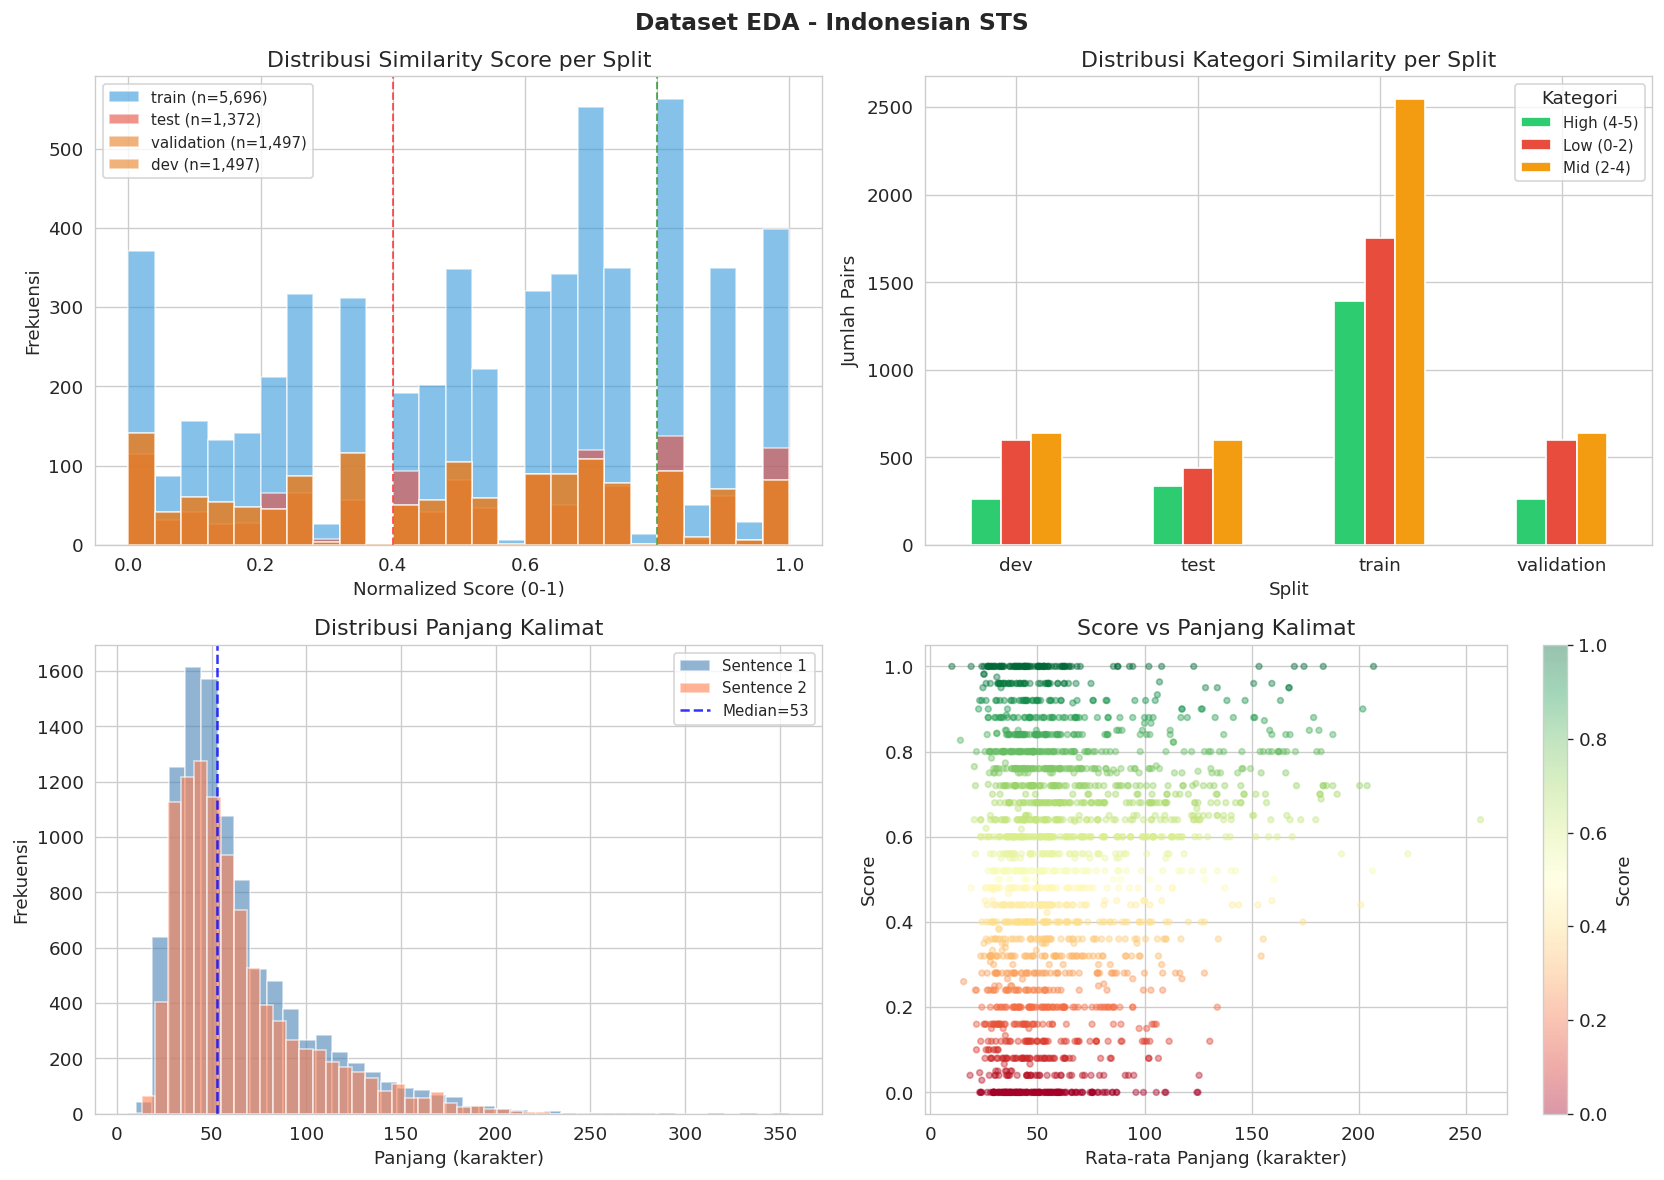

[OK] Plot tersimpan: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/eda_score_distribution.png


In [14]:
# ============================================================
# CELL 2.4b - EDA: visualisasi (4 plot)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset EDA - Indonesian STS', fontsize=14, fontweight='bold')
COLOR_MAP = {'train':'#3498db','dev':'#e67e22','validation':'#e67e22','test':'#e74c3c'}

# Plot 1: Score distribution per split
ax = axes[0, 0]
for sp in df_clean['split'].unique():
    sub = df_clean[df_clean['split']==sp]
    ax.hist(sub['score'], bins=25, alpha=0.6, label=f"{sp} (n={len(sub):,})",
            color=COLOR_MAP.get(sp,'gray'), edgecolor='white')
ax.axvline(0.4, color='red',   linestyle='--', alpha=0.6, linewidth=1.2)
ax.axvline(0.8, color='green', linestyle='--', alpha=0.6, linewidth=1.2)
ax.set_xlabel('Normalized Score (0-1)')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Similarity Score per Split')
ax.legend(fontsize=9)

# Plot 2: Category distribution
ax = axes[0, 1]
cat_colors = {'Low (0-2)':'#e74c3c','Mid (2-4)':'#f39c12','High (4-5)':'#2ecc71'}
cat_pivot.plot(kind='bar', ax=ax,
               color=[cat_colors.get(c,'gray') for c in cat_pivot.columns],
               edgecolor='white')
ax.set_title('Distribusi Kategori Similarity per Split')
ax.set_xlabel('Split'); ax.set_ylabel('Jumlah Pairs')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Kategori', fontsize=9)

# Plot 3: Sentence length distribution
ax = axes[1, 0]
ax.hist(df_clean['len_s1'], bins=40, alpha=0.6, label='Sentence 1',
        color='steelblue', edgecolor='white')
ax.hist(df_clean['len_s2'], bins=40, alpha=0.6, label='Sentence 2',
        color='coral', edgecolor='white')
ax.axvline(df_clean['len_s1'].median(), color='blue', linestyle='--', alpha=0.8,
           label=f'Median={df_clean["len_s1"].median():.0f}')
ax.set_xlabel('Panjang (karakter)'); ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Panjang Kalimat'); ax.legend(fontsize=9)

# Plot 4: Score vs length scatter
ax = axes[1, 1]
sample = df_clean.sample(min(2000, len(df_clean)), random_state=42)
sc = ax.scatter((sample['len_s1']+sample['len_s2'])/2, sample['score'],
                c=sample['score'], cmap='RdYlGn', alpha=0.4, s=12)
plt.colorbar(sc, ax=ax, label='Score')
ax.set_xlabel('Rata-rata Panjang (karakter)'); ax.set_ylabel('Score')
ax.set_title('Score vs Panjang Kalimat')

plt.tight_layout()
fig_path = PATHS['evaluation'] / 'eda_score_distribution.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"[OK] Plot tersimpan: {fig_path}")

In [15]:
# ============================================================
# CELL 2.5 - Build final splits (train/val/test)
# ============================================================
# TEST  -> split asli 'test'            (TIDAK disentuh sampai evaluasi akhir)
# VAL   -> split asli 'dev'/'validation'
# TRAIN -> split asli 'train'
# Fallback: jika val kosong -> auto-split 10% dari train

def get_split(df, keywords):
    mask = df['split'].str.lower().str.contains('|'.join(keywords))
    return df[mask].copy().reset_index(drop=True)

df_train = get_split(df_clean, ['train'])
df_val   = get_split(df_clean, ['dev', 'validation'])
df_test  = get_split(df_clean, ['test'])

if len(df_val) == 0:
    print("[WARN] Val set kosong -> auto-split 10% dari train...")
    val_idx  = df_train.sample(frac=0.10, random_state=42).index
    df_val   = df_train.loc[val_idx].copy().reset_index(drop=True)
    df_train = df_train.drop(val_idx).reset_index(drop=True)

print("=" * 50)
print("  FINAL DATASET SPLITS")
print("=" * 50)
for name, df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f"\n  {name:5}: {len(df):,} pairs")
    print(f"    score  mean={df['score'].mean():.4f}  "
          f"std={df['score'].std():.4f}  "
          f"range=[{df['score'].min():.2f}, {df['score'].max():.2f}]")
    if 'source' in df.columns:
        print(f"    sources: {df['source'].value_counts().to_dict()}")
print(f"\n  Total : {len(df_train)+len(df_val)+len(df_test):,}")
print("=" * 50)

  FINAL DATASET SPLITS

  Train: 5,696 pairs
    score  mean=0.5399  std=0.2930  range=[0.00, 1.00]
    sources: {'stsb_id_translated': 5696}

  Val  : 2,994 pairs
    score  mean=0.4721  std=0.2998  range=[0.00, 1.00]
    sources: {'stsb_id_translated': 2994}

  Test : 1,372 pairs
    score  mean=0.5207  std=0.3051  range=[0.00, 1.00]
    sources: {'stsb_id_translated': 1372}

  Total : 10,062


In [16]:
# ============================================================
# CELL 2.6 - Export train/val/test CSV ke Drive
# ============================================================

SPLITS_DIR = PATHS['splits']
FINAL_COLS = ['sentence1', 'sentence2', 'score_raw', 'score', 'source']

# Pastikan semua kolom ada
for df in [df_train, df_val, df_test]:
    for col in FINAL_COLS:
        if col not in df.columns:
            df[col] = 0.0 if col != 'source' else 'unknown'

print("[INFO] Exporting CSV splits ke Drive...")
for filename, df_export in [
    ('train_pairs.csv', df_train),
    ('val_pairs.csv',   df_val),
    ('test_pairs.csv',  df_test),
]:
    path = SPLITS_DIR / filename
    df_export[FINAL_COLS].to_csv(path, index=False)
    print(f"  [OK] {filename:<22} {len(df_export):>6,} rows -> {path}")

# all_pairs untuk referensi
df_clean[FINAL_COLS + ['split']].to_csv(SPLITS_DIR / 'all_pairs.csv', index=False)
print(f"  [OK] {'all_pairs.csv':<22} {len(df_clean):>6,} rows -> {SPLITS_DIR / 'all_pairs.csv'}")

[INFO] Exporting CSV splits ke Drive...
  [OK] train_pairs.csv         5,696 rows -> /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/datasets/splits/train_pairs.csv
  [OK] val_pairs.csv           2,994 rows -> /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/datasets/splits/val_pairs.csv
  [OK] test_pairs.csv          1,372 rows -> /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/datasets/splits/test_pairs.csv
  [OK] all_pairs.csv          10,062 rows -> /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/datasets/splits/all_pairs.csv


In [17]:
# ============================================================
# CELL 2.6b - Build simcse_sentences.txt
# ============================================================
# SimCSE butuh kalimat tunggal tanpa label.
# Sumber: kalimat unik dari TRAIN set saja.

print("[INFO] Building SimCSE sentence corpus...")

simcse_sentences = list(set(
    df_train['sentence1'].tolist() + df_train['sentence2'].tolist()
))
simcse_sentences = [s.strip() for s in simcse_sentences
                    if isinstance(s, str) and len(s.strip()) >= 10]
random.shuffle(simcse_sentences)

simcse_path = SPLITS_DIR / 'simcse_sentences.txt'
with open(simcse_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(simcse_sentences))

print(f"[OK] {len(simcse_sentences):,} sentences -> {simcse_path}")
print("\n  Sample 3 kalimat:")
for s in simcse_sentences[:3]:
    print(f"    - {s[:80]}")

[INFO] Building SimCSE sentence corpus...
[OK] 10,373 sentences -> /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/datasets/splits/simcse_sentences.txt

  Sample 3 kalimat:
    - Protes Thailand meningkat di tengah kekerasan
    - Dakwaan 32-count yang baru dibuka menyebutkan pencucian uang dan konspirasi dan 
    - Dow Jones rata-rata industri .DJI jatuh 79,43 poin, atau 0,86 persen, menjadi 9,


In [18]:
# ============================================================
# CELL 2.6c - Build mining_corpus.txt
# ============================================================
# Mining corpus untuk BM25 Hard Negative Mining (Stage 8).
# Sumber: train + val (BUKAN test -> cegah data leakage).

print("[INFO] Building Hard Negative Mining corpus...")

mining_sentences = list(set(
    df_train['sentence1'].tolist() + df_train['sentence2'].tolist() +
    df_val['sentence1'].tolist()   + df_val['sentence2'].tolist()
))
mining_sentences = [s.strip() for s in mining_sentences
                    if isinstance(s, str) and len(s.strip()) >= 10]
random.shuffle(mining_sentences)

mining_path = PATHS['mining_corpus'] / 'mining_corpus.txt'
with open(mining_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(mining_sentences))

print(f"[OK] {len(mining_sentences):,} sentences -> {mining_path}")

[INFO] Building Hard Negative Mining corpus...
[OK] 12,986 sentences -> /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/datasets/mining-corpus/mining_corpus.txt


In [19]:
# ============================================================
# CELL 2.7 - Export dataset_stats.json
# ============================================================

def split_stats(df):
    s = df['score']
    return {
        'n_pairs'    : int(len(df)),
        'score_mean' : round(float(s.mean()), 4),
        'score_std'  : round(float(s.std()),  4),
        'score_min'  : round(float(s.min()),  4),
        'score_max'  : round(float(s.max()),  4),
        'n_low'      : int((s < 0.4).sum()),
        'n_mid'      : int(((s >= 0.4) & (s < 0.8)).sum()),
        'n_high'     : int((s >= 0.8).sum()),
        'avg_len_s1' : round(float(df['sentence1'].str.len().mean()), 1),
        'avg_len_s2' : round(float(df['sentence2'].str.len().mean()), 1),
        'sources'    : df['source'].value_counts().to_dict() if 'source' in df.columns else {},
    }

stats = {
    'project'            : 'Indonesian STS Embeddings',
    'base_model'         : 'indobenchmark/indobert-base-p1',
    'score_scale'        : '0-1 (normalized from 0-5)',
    'n_simcse_sentences' : len(simcse_sentences),
    'n_mining_corpus'    : len(mining_sentences),
    'splits': {
        'train': split_stats(df_train),
        'val'  : split_stats(df_val),
        'test' : split_stats(df_test),
    }
}

stats_path = PATHS['evaluation'] / 'dataset_stats.json'
with open(stats_path, 'w', encoding='utf-8') as f:
    json.dump(stats, f, indent=2, ensure_ascii=False)

print(f"[OK] dataset_stats.json -> {stats_path}")
print(json.dumps(stats, indent=2, ensure_ascii=False))

[OK] dataset_stats.json -> /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/dataset_stats.json
{
  "project": "Indonesian STS Embeddings",
  "base_model": "indobenchmark/indobert-base-p1",
  "score_scale": "0-1 (normalized from 0-5)",
  "n_simcse_sentences": 10373,
  "n_mining_corpus": 12986,
  "splits": {
    "train": {
      "n_pairs": 5696,
      "score_mean": 0.5399,
      "score_std": 0.293,
      "score_min": 0.0,
      "score_max": 1.0,
      "n_low": 1756,
      "n_mid": 2549,
      "n_high": 1391,
      "avg_len_s1": 62.9,
      "avg_len_s2": 62.6,
      "sources": {
        "stsb_id_translated": 5696
      }
    },
    "val": {
      "n_pairs": 2994,
      "score_mean": 0.4721,
      "score_std": 0.2998,
      "score_min": 0.0,
      "score_max": 1.0,
      "n_low": 1196,
      "n_mid": 1274,
      "n_high": 524,
      "avg_len_s1": 69.0,
      "avg_len_s2": 69.1,
      "sources": {
        "stsb_id_translated": 2994
      }
    },
    "test": {
      "

In [20]:
# ============================================================
# CELL 2.8 - Write src/data_loader.py ke Drive
# ============================================================

from pathlib import Path

SRC_DIR = Path(PROJECT_ROOT) / 'src'
SRC_DIR.mkdir(parents=True, exist_ok=True)

# -- __init__.py
(SRC_DIR / '__init__.py').write_text(
    '# Indonesian STS Embeddings - src package\n',
    encoding='utf-8'
)
print(f"[OK] {SRC_DIR / '__init__.py'}")

# -- data_loader.py
# Ditulis baris per baris ke file langsung, tanpa multiline string
# untuk menghindari konflik quote escaping.

lines = [
    'import re, json, random, unicodedata',
    'from pathlib import Path',
    'from typing import Dict, List, Optional, Tuple, Union',
    'import pandas as pd',
    'from sentence_transformers import InputExample',
    '',
    '',
    '# --- TEXT CLEANING ---',
    '',
    'def clean_text(text: str) -> str:',
    '    if not isinstance(text, str): return ""',
    '    text = unicodedata.normalize("NFC", text)',
    r'    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", "", text)',
    r'    text = re.sub(r"[\n\t\r]+", " ", text)',
    r'    text = re.sub(r" +", " ", text)',
    '    return text.strip()',
    '',
    '',
    '# --- LOAD CSV SPLITS ---',
    '',
    'def load_splits(',
    '    splits_dir: Union[str, Path],',
    "    splits: Tuple[str, ...] = ('train', 'val', 'test'),",
    "    score_col: str = 'score'",
    ') -> Dict[str, pd.DataFrame]:',
    '    splits_dir = Path(splits_dir)',
    '    result = {}',
    '    for split in splits:',
    '        path = splits_dir / f"{split}_pairs.csv"',
    '        if not path.exists():',
    '            raise FileNotFoundError(',
    '                f"Split tidak ditemukan: {path}\\n"',
    '                f"Pastikan Stage 2 sudah dijalankan."',
    '            )',
    '        df = pd.read_csv(path)',
    "        missing = {'sentence1', 'sentence2', score_col} - set(df.columns)",
    '        if missing:',
    '            raise ValueError(f"Kolom tidak ada di {path.name}: {missing}")',
    '        result[split] = df',
    '        print(f"[OK] {split}: {len(df):,} pairs  "',
    '              f"score [{df[score_col].min():.3f} - {df[score_col].max():.3f}]")',
    '    return result',
    '',
    '',
    '# --- INPUT EXAMPLE BUILDERS ---',
    '',
    'def df_to_input_examples(',
    '    df: pd.DataFrame,',
    "    score_col: str = 'score'",
    ') -> List[InputExample]:',
    '    return [',
    '        InputExample(',
    "            texts=[str(row['sentence1']), str(row['sentence2'])],",
    '            label=float(row[score_col])',
    '        )',
    '        for _, row in df.iterrows()',
    '    ]',
    '',
    '',
    'def df_to_simcse_examples(sentences: List[str]) -> List[InputExample]:',
    '    return [',
    '        InputExample(texts=[s, s])',
    '        for s in sentences',
    '        if len(s.strip()) >= 10',
    '    ]',
    '',
    '',
    'def build_triplet_examples(triplets_csv: Union[str, Path]) -> List[InputExample]:',
    '    df = pd.read_csv(triplets_csv)',
    '    examples = [',
    '        InputExample(texts=[',
    "            str(row['anchor']),",
    "            str(row['positive']),",
    "            str(row['hard_negative'])",
    '        ])',
    '        for _, row in df.iterrows()',
    '    ]',
    '    print(f"[OK] Loaded {len(examples):,} hard negative triplets.")',
    '    return examples',
    '',
    '',
    '# --- CORPUS LOADERS ---',
    '',
    'def load_simcse_corpus(',
    '    txt_path: Union[str, Path],',
    '    max_sentences: Optional[int] = None,',
    '    shuffle: bool = True,',
    '    seed: int = 42',
    ') -> List[str]:',
    '    txt_path = Path(txt_path)',
    '    if not txt_path.exists():',
    '        raise FileNotFoundError(f"SimCSE corpus tidak ditemukan: {txt_path}")',
    '    with open(txt_path, encoding="utf-8") as f:',
    '        sents = [l.strip() for l in f if l.strip()]',
    '    if shuffle:',
    '        random.seed(seed)',
    '        random.shuffle(sents)',
    '    if max_sentences:',
    '        sents = sents[:max_sentences]',
    '    print(f"[OK] {len(sents):,} sentences for SimCSE.")',
    '    return sents',
    '',
    '',
    'def load_mining_corpus(txt_path: Union[str, Path]) -> List[str]:',
    '    txt_path = Path(txt_path)',
    '    if not txt_path.exists():',
    '        raise FileNotFoundError(f"Mining corpus tidak ditemukan: {txt_path}")',
    '    with open(txt_path, encoding="utf-8") as f:',
    '        sents = [l.strip() for l in f if l.strip()]',
    '    print(f"[OK] {len(sents):,} sentences for BM25 mining.")',
    '    return sents',
    '',
    '',
    '# --- UTILITIES ---',
    '',
    'def load_dataset_stats(stats_json: Union[str, Path]) -> Dict:',
    '    with open(stats_json, encoding="utf-8") as f:',
    '        return json.load(f)',
    '',
    '',
    'def print_split_summary(',
    '    data: Dict[str, pd.DataFrame],',
    "    score_col: str = 'score'",
    ') -> None:',
    '    print("\\n" + "=" * 55)',
    '    print("  DATASET SPLIT SUMMARY")',
    '    print("=" * 55)',
    '    total = 0',
    '    for name, df in data.items():',
    '        n = len(df)',
    '        total += n',
    '        s = df[score_col]',
    '        n_low  = (s < 0.4).sum()',
    '        n_mid  = ((s >= 0.4) & (s < 0.8)).sum()',
    '        n_high = (s >= 0.8).sum()',
    '        print(f"\\n  {name.upper():6}: {n:,} pairs")',
    '        print(f"    Score: mean={s.mean():.3f}  std={s.std():.3f}")',
    '        print(f"    Low={n_low:,}({n_low/n*100:.0f}%)  "',
    '              f"Mid={n_mid:,}({n_mid/n*100:.0f}%)  "',
    '              f"High={n_high:,}({n_high/n*100:.0f}%)")',
    '    print(f"\\n  TOTAL: {total:,} pairs")',
    '    print("=" * 55)',
]

data_loader_path = SRC_DIR / 'data_loader.py'
data_loader_path.write_text('\n'.join(lines), encoding='utf-8')
print(f"[OK] {data_loader_path}")
print(f"     {len(lines)} lines ditulis.")

# -- Verifikasi import
print("\n[INFO] Verifikasi import...")
import importlib
if 'src.data_loader' in sys.modules:
    importlib.reload(sys.modules['src.data_loader'])
if str(Path(PROJECT_ROOT)) not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.data_loader import (
    load_splits, load_simcse_corpus, load_mining_corpus,
    df_to_input_examples, df_to_simcse_examples,
    build_triplet_examples, print_split_summary
)
print("[OK] Semua fungsi berhasil di-import:")
print("     load_splits, load_simcse_corpus, load_mining_corpus")
print("     df_to_input_examples, df_to_simcse_examples")
print("     build_triplet_examples, print_split_summary")
print("\n[OK] CELL 2.8 selesai.")

[OK] /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/src/__init__.py
[OK] /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/src/data_loader.py
     142 lines ditulis.

[INFO] Verifikasi import...
[OK] Semua fungsi berhasil di-import:
     load_splits, load_simcse_corpus, load_mining_corpus
     df_to_input_examples, df_to_simcse_examples
     build_triplet_examples, print_split_summary

[OK] CELL 2.8 selesai.


In [21]:
# ============================================================
# CELL 2.9 - Sanity check & verifikasi semua file output
# ============================================================

print("[INFO] Sanity check semua file output Stage 2...\n")
checks = []

# [1] CSV splits
for fname, expected in [
    ('train_pairs.csv', len(df_train)),
    ('val_pairs.csv',   len(df_val)),
    ('test_pairs.csv',  len(df_test)),
]:
    try:
        df_chk = pd.read_csv(SPLITS_DIR / fname)
        assert len(df_chk) == expected
        assert {'sentence1','sentence2','score'}.issubset(df_chk.columns)
        assert df_chk['score'].between(0,1).all()
        checks.append((fname, True, f"{len(df_chk):,} rows"))
    except Exception as e:
        checks.append((fname, False, str(e)))

# [2] SimCSE corpus
try:
    lines = open(SPLITS_DIR / 'simcse_sentences.txt', encoding='utf-8').readlines()
    assert len(lines) >= 100
    checks.append(('simcse_sentences.txt', True, f"{len(lines):,} sentences"))
except Exception as e:
    checks.append(('simcse_sentences.txt', False, str(e)))

# [3] Mining corpus
try:
    lines = open(PATHS['mining_corpus'] / 'mining_corpus.txt', encoding='utf-8').readlines()
    assert len(lines) >= 100
    checks.append(('mining_corpus.txt', True, f"{len(lines):,} sentences"))
except Exception as e:
    checks.append(('mining_corpus.txt', False, str(e)))

# [4] dataset_stats.json
try:
    s = json.load(open(PATHS['evaluation'] / 'dataset_stats.json'))
    assert 'splits' in s and 'train' in s['splits']
    checks.append(('dataset_stats.json', True, 'valid JSON'))
except Exception as e:
    checks.append(('dataset_stats.json', False, str(e)))

# [5] src/data_loader.py
try:
    dl = (Path(PROJECT_ROOT) / 'src' / 'data_loader.py').read_text(encoding='utf-8')
    for fn in ['def load_splits', 'def df_to_input_examples',
               'def load_simcse_corpus', 'def load_mining_corpus',
               'def print_split_summary']:
        assert fn in dl, f"{fn} tidak ditemukan"
    checks.append(('src/data_loader.py', True, '5 fungsi terverifikasi'))
except Exception as e:
    checks.append(('src/data_loader.py', False, str(e)))

# -- Print hasil
print(f"  {'File':<28} {'Status':<6}  Info")
print("  " + "-" * 62)
passed = 0
for fname, ok, info in checks:
    icon = "OK" if ok else "FAIL"
    print(f"  {fname:<28} [{icon:<4}]  {info}")
    if ok: passed += 1

print("\n  " + "-" * 62)
result = "ALL PASSED" if passed == len(checks) else f"{len(checks)-passed} FAILED"
print(f"  Result: {result}  ({passed}/{len(checks)})")

# -- Sample output jika semua OK
if passed == len(checks):
    print("\n  Sample train_pairs.csv:")
    rows = pd.read_csv(SPLITS_DIR / 'train_pairs.csv').sample(2, random_state=99)
    for _, row in rows.iterrows():
        print(f"    S1   : {str(row['sentence1'])[:65]}")
        print(f"    S2   : {str(row['sentence2'])[:65]}")
        print(f"    Score: {row['score']:.4f}\n")

print("=" * 55)
print("  Stage 2 Complete!")
print("  Next: 03_baseline_model.ipynb")
print("=" * 55)

[INFO] Sanity check semua file output Stage 2...

  File                         Status  Info
  --------------------------------------------------------------
  train_pairs.csv              [OK  ]  5,696 rows
  val_pairs.csv                [OK  ]  2,994 rows
  test_pairs.csv               [OK  ]  1,372 rows
  simcse_sentences.txt         [OK  ]  10,373 sentences
  mining_corpus.txt            [OK  ]  12,986 sentences
  dataset_stats.json           [OK  ]  valid JSON
  src/data_loader.py           [OK  ]  5 fungsi terverifikasi

  --------------------------------------------------------------
  Result: ALL PASSED  (7/7)

  Sample train_pairs.csv:
    S1   : Seekor anjing coklat mengarungi air.
    S2   : Seekor anjing memercikkan air keruh.
    Score: 0.7200

    S1   : Walikota Newark menyelamatkan tetangga dari kebakaran
    S2   : Walikota Newark menyelamatkan tetangga dari rumah terbakar
    Score: 0.8400

  Stage 2 Complete!
  Next: 03_baseline_model.ipynb


---

## Stage 2 Complete - Output Summary

```
MyDrive/AI-Projects/sts-indonesian-embeddings/
|
+-- src/
|   +-- __init__.py
|   +-- data_loader.py          <- di-import Stage 3-10
|
+-- datasets/
|   +-- splits/
|   |   +-- train_pairs.csv     <- Stage 5, 7, 9
|   |   +-- val_pairs.csv       <- Stage 6, 10
|   |   +-- test_pairs.csv      <- Stage 10 (evaluasi akhir ONLY)
|   |   +-- all_pairs.csv       <- referensi
|   |   +-- simcse_sentences.txt<- Stage 7 (SimCSE training)
|   +-- mining-corpus/
|       +-- mining_corpus.txt   <- Stage 8 (BM25 Hard Negative Mining)
|
+-- evaluation/
    +-- dataset_stats.json
    +-- eda_score_distribution.png
```

### Estimasi Waktu
| Sub-task | Estimasi |
|----------|----------|
| Download datasets (pertama kali) | ~2-3 menit |
| Normalisasi + cleaning | ~30 detik |
| EDA + visualisasi | ~1 menit |
| Export CSV + write data_loader.py | ~1 menit |
| Sanity check | ~15 detik |
| **Total** | **~5-7 menit** |

---
**Next:** `03_baseline_model.ipynb` - Zero-Shot Baseline (IndoBERT + Mean Pooling)